In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
data=pd.read_csv("/content/drive/MyDrive/intern/Dataset1.csv")
data.head(10)

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0
5,2,108,KRMI,265,232,199,166,KARMALI,1,21:04:00,21:06:00,33
6,3,108,THVM,355,304,253,202,THIVIM,1,21:26:00,21:28:00,51
7,4,108,SWV,515,432,349,266,SAWANTWADI R,1,22:25:00,00:00:00,83
8,1,128,MAO,100,100,100,100,MADGOAN JN.,1,19:40:00,19:40:00,0
9,2,128,KRMI,265,232,199,166,KARMALI,1,20:18:00,20:20:00,33


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186074 entries, 0 to 186073
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   SN              186074 non-null  int64 
 1   Train_No        186074 non-null  int64 
 2   Station_Code    186074 non-null  object
 3   1A              186074 non-null  int64 
 4   2A              186074 non-null  int64 
 5   3A              186074 non-null  int64 
 6   SL              186074 non-null  int64 
 7   Station_Name    186074 non-null  object
 8   Route_Number    186074 non-null  int64 
 9   Arrival_time    186074 non-null  object
 10  Departure_Time  186074 non-null  object
 11  Distance        186074 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 17.0+ MB


In [5]:
print("\nMissing values per column:")
display(data.isnull().sum())


Missing values per column:


,0
SN,0
Train_No,0
Station_Code,0
1A,0
2A,0
3A,0
SL,0
Station_Name,0
Route_Number,0
Arrival_time,0


In [6]:
display(data.describe())

,SN,Train_No,1A,2A,3A,SL,Route_Number,Distance
count,186074.000000,186074.000000,186074.000000,186074.000000,186074.000000,186074.000000,186074.0,186074.000000
mean,13.914695,42157.747455,1506.769189,1225.415351,944.061513,662.735777,1.0,281.353838
std,12.779368,25090.080221,2418.719821,1934.975856,1451.231892,967.524012,0.0,483.743964
min,1.000000,107.000000,100.000000,100.000000,100.000000,100.000000,1.0,0.000000
25%,5.000000,17225.000000,215.000000,192.000000,169.000000,146.000000,1.0,23.000000
50%,11.000000,40050.000000,465.000000,392.000000,319.000000,246.000000,1.0,73.000000
75%,18.000000,57550.000000,1555.000000,1264.000000,973.000000,682.000000,1.0,291.000000
max,118.000000,99908.000000,21400.000000,17140.000000,12880.000000,8620.000000,1.0,4260.000000


In [9]:

data['Arrival_time_dt'] = pd.to_datetime(data['Arrival_time'], format='%H:%M:%S', errors='coerce').dt.time
data['Departure_Time_dt'] = pd.to_datetime(data['Departure_Time'], format='%H:%M:%S', errors='coerce').dt.time

print(f"Number of NaT values in Arrival_time_dt: {data['Arrival_time_dt'].isnull().sum()}")
print(f"Number of NaT values in Departure_Time_dt: {data['Departure_Time_dt'].isnull().sum()}")

display(data[['Arrival_time', 'Arrival_time_dt', 'Departure_Time', 'Departure_Time_dt']].head())

Number of NaT values in Arrival_time_dt: 0
Number of NaT values in Departure_Time_dt: 0


,Arrival_time,Arrival_time_dt,Departure_Time,Departure_Time_dt
0,00:00:00,00:00:00,10:25:00,10:25:00
1,11:06:00,11:06:00,11:08:00,11:08:00
2,11:28:00,11:28:00,11:30:00,11:30:00
3,12:10:00,12:10:00,00:00:00,00:00:00
4,00:00:00,00:00:00,20:30:00,20:30:00


In [7]:
print("Unique Station Codes:", data['Station_Code'].nunique())
print("Unique Station Names:", data['Station_Name'].nunique())
print("Unique Route Numbers:", data['Route_Number'].nunique())

print("\nTop 10 unique Station Codes:")
display(data['Station_Code'].value_counts().head(10))
print("\nTop 10 unique Station Names:")
display(data['Station_Name'].value_counts().head(10))

Unique Station Codes: 8147
Unique Station Names: 8099
Unique Route Numbers: 1

Top 10 unique Station Codes:


,count
Station_Code,
CSMT,1027
KYN,828
TNA,796
SDAH,745
MSB,738
HWH,699
DR,567
DDJ,463
CLA,462



Top 10 unique Station Names:


,count
Station_Name,
CST-MUMBAI,1027
KALYAN JN,828
THANE,796
SEALDAH,745
CHENNAI BEAC,738
HOWRAH JN.,699
DADAR,598
DUM DUM JN.,463
KURLA,462


In [8]:
print("Unique SN values:", data['SN'].unique())
print("\nTop 10 Train Numbers:")
display(data['Train_No'].value_counts().head(10))

print("\nDistance min, max, mean, and std:")
display(data['Distance'].describe())

Unique SN values: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118]

Top 10 Train Numbers:


,count
Train_No,
53041,118
13007,112
13049,111
58112,109
13008,108
53042,107
13050,106
58111,102
19019,98



Distance min, max, mean, and std:


,Distance
count,186074.000000
mean,281.353838
std,483.743964
min,0.000000
25%,23.000000
50%,73.000000
75%,291.000000
max,4260.000000


Preprocessing

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("Original shape:", data.shape)
print("Missing values:", data.isnull().sum().sum())
print("Duplicate rows:", data.duplicated().sum())

data = data.dropna()
data = data.drop_duplicates()

print("After cleaning shape:", data.shape)
#
def time_to_minutes(t):
    try:
        h, m, s = map(int, str(t).split(':'))
        return h * 60 + m
    except:
        return np.nan

data["arr_minutes"] = data["Arrival_time"].apply(time_to_minutes)
data["dep_minutes"] = data["Departure_Time"].apply(time_to_minutes)

print("\nTime conversion sample:")
print(data[["Arrival_time", "arr_minutes",
            "Departure_Time", "dep_minutes"]].head(5))

data = data.sort_values(["Train_No", "Distance"])

start_time = data.groupby("Train_No")["dep_minutes"].first()
end_time   = data.groupby("Train_No")["arr_minutes"].last()
#
train_data = pd.DataFrame()
train_data["Train_No"]                 = start_time.index
train_data["Start_Time_Minutes"]       = start_time.values
train_data["End_Time_Minutes"]         = end_time.values
train_data["Journey_Duration_Minutes"] = (
    train_data["End_Time_Minutes"] - train_data["Start_Time_Minutes"]
)

train_data["Journey_Duration_Minutes"] = train_data["Journey_Duration_Minutes"].apply(
    lambda x: x if x > 0 else x + (24 * 60)
)

print("\nDuration sample:")
print(train_data.head(5))
#
features = data.groupby("Train_No").agg(
    Total_Distance = ("Distance",     "max"),
    Total_Stops    = ("Station_Name", "count"),
    Avg_1A_Fare    = ("1A",           "mean"),
    Avg_2A_Fare    = ("2A",           "mean"),
    Avg_3A_Fare    = ("3A",           "mean"),
    Avg_SL_Fare    = ("SL",           "mean"),
    Dep_Hour       = ("dep_minutes",  "first"),
).reset_index()

features["Dist_Per_Stop"] = features["Total_Distance"] / features["Total_Stops"]

ml_data = features.merge(
    train_data[["Train_No", "Journey_Duration_Minutes"]],
    on="Train_No", how="inner"
)
#
ml_data = ml_data.dropna()
ml_data = ml_data[
    (ml_data["Journey_Duration_Minutes"] > 0) &
    (ml_data["Journey_Duration_Minutes"] < 5000)
].reset_index(drop=True)

print("\nFinal ML dataset shape:", ml_data.shape)
print(ml_data.head(5))



Original shape: (186074, 14)
Missing values: 0
Duplicate rows: 0
After cleaning shape: (186074, 14)

Time conversion sample:
  Arrival_time  arr_minutes Departure_Time  dep_minutes
0     00:00:00            0       10:25:00          625
1     11:06:00          666       11:08:00          668
2     11:28:00          688       11:30:00          690
3     12:10:00          730       00:00:00            0
4     00:00:00            0       20:30:00         1230

Duration sample:
   Train_No  Start_Time_Minutes  End_Time_Minutes  Journey_Duration_Minutes
0       107                 625               730                       105
1       108                1230              1345                       115
2       128                1180              1065                      1325
3       290                1110               150                       480
4       401                1290               600                       750

Final ML dataset shape: (11113, 10)
   Train_No  Total_Distance 

In [12]:
FEATURE_COLS = ["Total_Distance", "Total_Stops", "Avg_1A_Fare",
                "Avg_2A_Fare", "Avg_3A_Fare", "Avg_SL_Fare",
                "Dist_Per_Stop", "Dep_Hour"]

X = ml_data[FEATURE_COLS]
y = ml_data["Journey_Duration_Minutes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n Preprocessing complete!")
print(f"  Training set : {len(X_train):,} samples")
print(f"  Testing set  : {len(X_test):,} samples")
print(f"  Features     : {len(FEATURE_COLS)}")


 Preprocessing complete!
  Training set : 8,890 samples
  Testing set  : 2,223 samples
  Features     : 8


In [13]:
from google.colab import drive
import os


FEATURE_COLS = ["Total_Distance", "Total_Stops", "Avg_1A_Fare",
                "Avg_2A_Fare", "Avg_3A_Fare", "Avg_SL_Fare",
                "Dist_Per_Stop", "Dep_Hour"]

X = ml_data[FEATURE_COLS]
y = ml_data["Journey_Duration_Minutes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

save_path = "/content/drive/MyDrive/intern/"


X_train.to_csv(save_path + "X_train.csv",       index=False)
X_test.to_csv(save_path  + "X_test.csv",        index=False)
y_train.to_csv(save_path + "y_train.csv",       index=False)
y_test.to_csv(save_path  + "y_test.csv",        index=False)


pd.DataFrame(X_train_scaled,
             columns=FEATURE_COLS).to_csv(save_path + "X_train_scaled.csv", index=False)
pd.DataFrame(X_test_scaled,
             columns=FEATURE_COLS).to_csv(save_path + "X_test_scaled.csv",  index=False)

print(" Preprocessing complete!")
print(f"  Training set : {len(X_train):,} samples")
print(f"  Testing set  : {len(X_test):,} samples")
print(f"  Features     : {len(FEATURE_COLS)}")
print(f"\n Files saved to {save_path}:")

 Preprocessing complete!
  Training set : 8,890 samples
  Testing set  : 2,223 samples
  Features     : 8

 Files saved to /content/drive/MyDrive/intern/:


Linear Regression Results:
  MAE  : 137.96 minutes
  RMSE : 221.21 minutes
  R²   : 0.5230


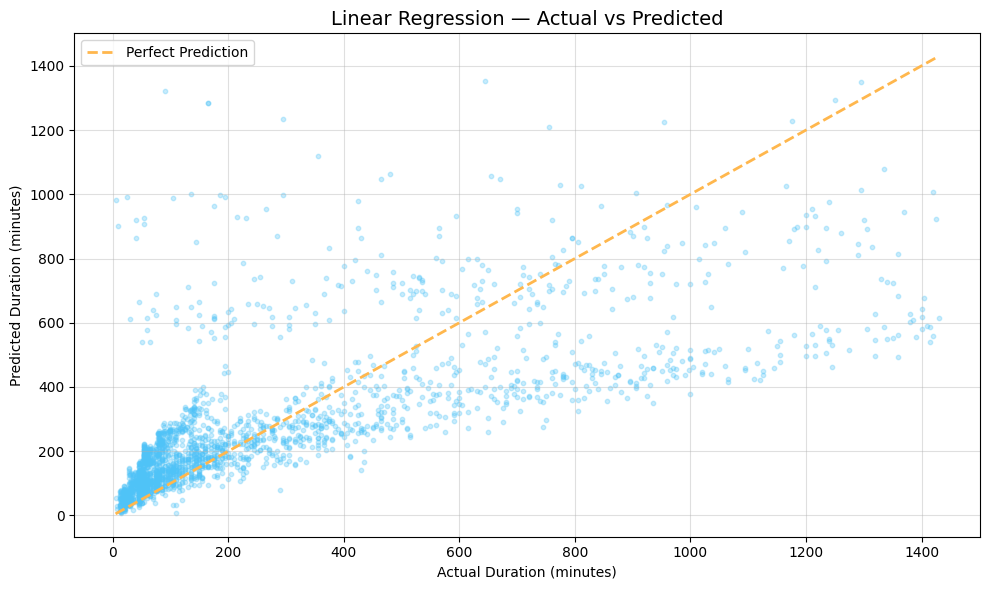

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2   = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"  MAE  : {mae:.2f} minutes")
print(f"  RMSE : {rmse:.2f} minutes")
print(f"  R²   : {r2:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.3, s=10, color="#4FC3F7")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="#FFB74D", linewidth=2, linestyle="--", label="Perfect Prediction")
plt.title("Linear Regression — Actual vs Predicted", fontsize=14)
plt.xlabel("Actual Duration (minutes)")
plt.ylabel("Predicted Duration (minutes)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [16]:
import joblib
import os

model_path = "/content/drive/MyDrive/intern/models/"
os.makedirs(model_path, exist_ok=True)


def save_model(model, model_name):
    path = model_path + model_name + ".pkl"
    joblib.dump(model, path)
    print(f" {model_name} saved to {path}")

def load_model(model_name):
    path = model_path + model_name + ".pkl"
    model = joblib.load(path)
    print(f" {model_name} loaded from {path}")
    return model


save_model(lr_model, "linear_regression")


 linear_regression saved to /content/drive/MyDrive/intern/models/linear_regression.pkl


On average thia prediction is OFF by 137 minutes (about 2.3 hours)

Example:
  Actual duration   →  300 minutes (5 hours)
  
  Model predicts    →  162 to 438 minutes  (±137 min)

Decision Tree with depth/overfitting analysis

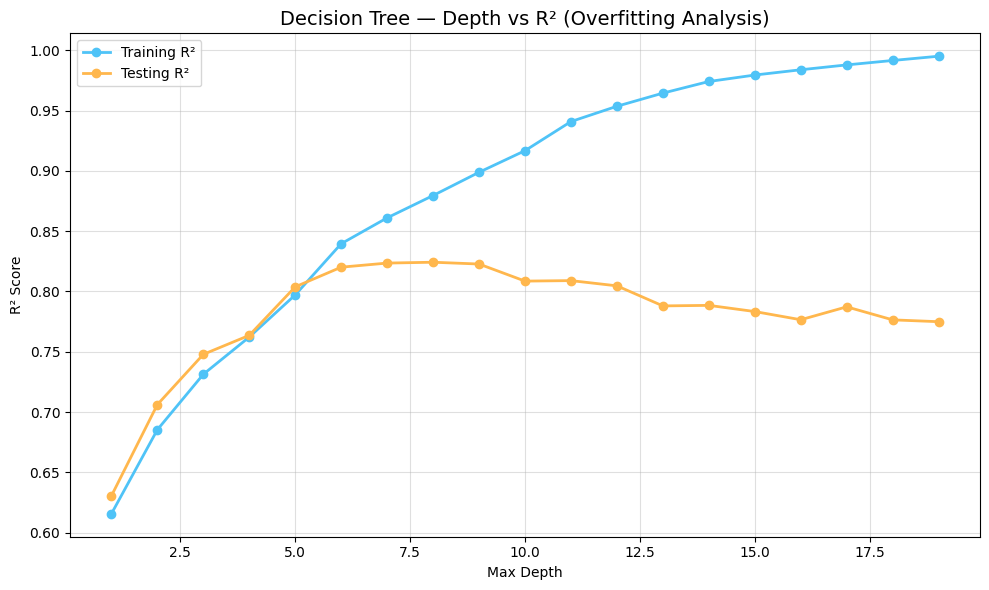

Best depth: 8

Decision Tree Results:
  Best Depth : 8
  MAE        : 53.47 minutes
  RMSE       : 134.29 minutes
  R²         : 0.8242


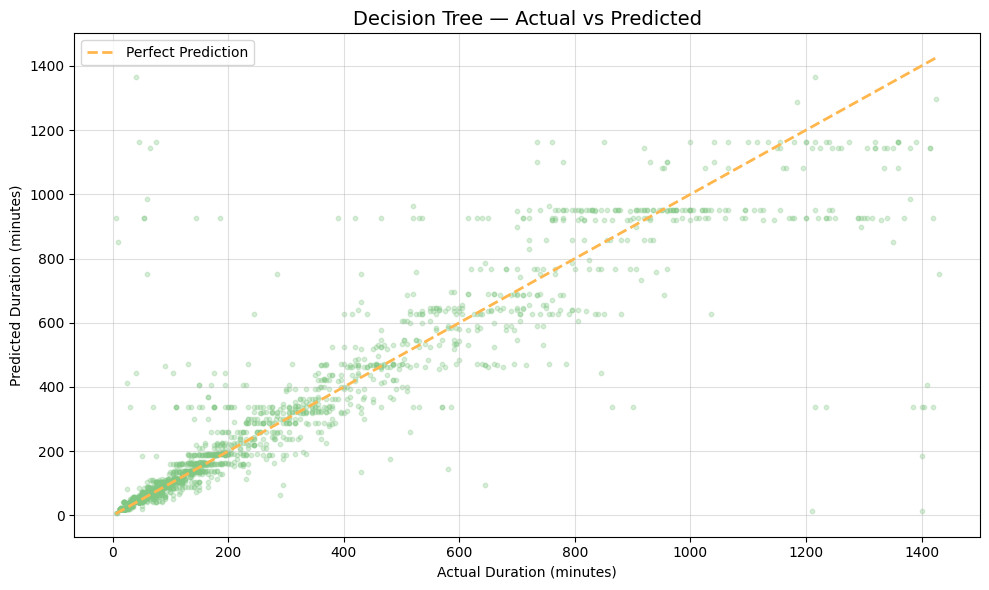

 decision_tree saved to /content/drive/MyDrive/intern/models/decision_tree.pkl


In [17]:
from sklearn.tree import DecisionTreeRegressor

train_scores = []
test_scores  = []
depths       = range(1, 20)

for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, dt.predict(X_train)))
    test_scores.append(r2_score(y_test,  dt.predict(X_test)))


plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, color="#4FC3F7", linewidth=2, marker="o", label="Training R²")
plt.plot(depths, test_scores,  color="#FFB74D", linewidth=2, marker="o", label="Testing R²")
plt.title("Decision Tree — Depth vs R² (Overfitting Analysis)", fontsize=14)
plt.xlabel("Max Depth")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

best_depth = depths[test_scores.index(max(test_scores))]
print(f"Best depth: {best_depth}")


dt_model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_dt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2   = r2_score(y_test, y_pred_dt)

print("\nDecision Tree Results:")
print(f"  Best Depth : {best_depth}")
print(f"  MAE        : {mae:.2f} minutes")
print(f"  RMSE       : {rmse:.2f} minutes")
print(f"  R²         : {r2:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.3, s=10, color="#81C784")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="#FFB74D", linewidth=2, linestyle="--", label="Perfect Prediction")
plt.title("Decision Tree — Actual vs Predicted", fontsize=14)
plt.xlabel("Actual Duration (minutes)")
plt.ylabel("Predicted Duration (minutes)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


save_model(dt_model, "decision_tree")


MAE  : 53.47 minutes

on average prediction is off by ~53 minutes (under 1 hour)

RMSE : 134.29 minutes

 some journeys still have large errors

likely the very long distance trains are harder to predict

R²   : 0.8242

model explains 82% of the data

good result for a Decision Tree

Linear Regression — Scaling Comparison:
Scaling                   MAE     RMSE       R²
────────────────────────────────────────────────
No Scaling             137.96   221.21   0.5230
Standard Scaler        137.96   221.21   0.5230
MinMax Scaler          137.96   221.21   0.5230

Decision Tree — Scaling Comparison:
Scaling                   MAE     RMSE       R²
────────────────────────────────────────────────
No Scaling              53.47   134.29   0.8242
Standard Scaler         53.47   134.29   0.8242
MinMax Scaler           53.47   134.29   0.8242


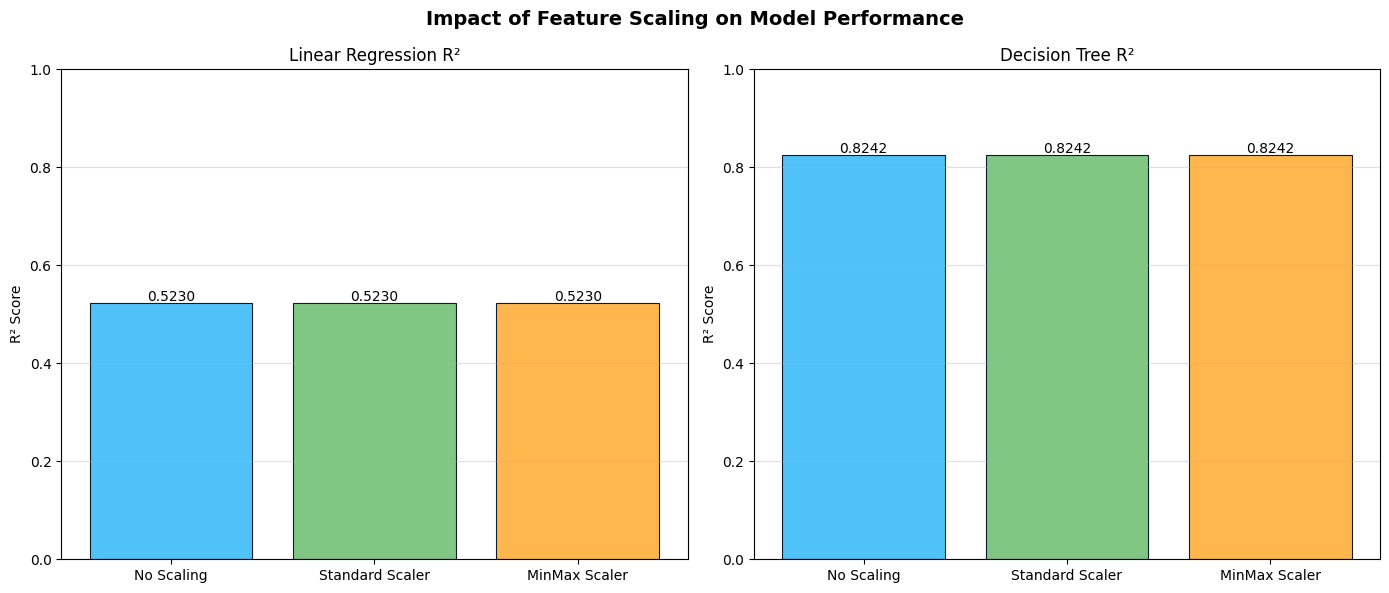

In [18]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

standard_scaler = StandardScaler()
minmax_scaler   = MinMaxScaler()

X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard  = standard_scaler.transform(X_test)

X_train_minmax   = minmax_scaler.fit_transform(X_train)
X_test_minmax    = minmax_scaler.transform(X_test)

print("Linear Regression — Scaling Comparison:")
print(f"{'Scaling':<20} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("─" * 48)

scaling_options = {
    "No Scaling"       : (X_train,          X_test),
    "Standard Scaler"  : (X_train_standard, X_test_standard),
    "MinMax Scaler"    : (X_train_minmax,   X_test_minmax),
}

lr_scaling_results = {}
for name, (Xtr, Xte) in scaling_options.items():
    lr = LinearRegression()
    lr.fit(Xtr, y_train)
    pred = lr.predict(Xte)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    lr_scaling_results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name:<20} {mae:>8.2f} {rmse:>8.2f} {r2:>8.4f}")

print("\nDecision Tree — Scaling Comparison:")
print(f"{'Scaling':<20} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("─" * 48)

dt_scaling_results = {}
for name, (Xtr, Xte) in scaling_options.items():
    dt = DecisionTreeRegressor(max_depth=8, random_state=42)
    dt.fit(Xtr, y_train)
    pred = dt.predict(Xte)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    dt_scaling_results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name:<20} {mae:>8.2f} {rmse:>8.2f} {r2:>8.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Impact of Feature Scaling on Model Performance", fontsize=14, fontweight="bold")

scale_names = list(scaling_options.keys())

# Linear Regression
lr_r2s = [lr_scaling_results[s]["R2"] for s in scale_names]
axes[0].bar(scale_names, lr_r2s, color=["#4FC3F7","#81C784","#FFB74D"],
            edgecolor="#0F1B2D", linewidth=0.8)
for i, v in enumerate(lr_r2s):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=10)
axes[0].set_title("Linear Regression R²", fontsize=12)
axes[0].set_ylabel("R² Score")
axes[0].set_ylim(0, 1)
axes[0].grid(True, axis="y", alpha=0.4)

# Decision Tree
dt_r2s = [dt_scaling_results[s]["R2"] for s in scale_names]
axes[1].bar(scale_names, dt_r2s, color=["#4FC3F7","#81C784","#FFB74D"],
            edgecolor="#0F1B2D", linewidth=0.8)
for i, v in enumerate(dt_r2s):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=10)
axes[1].set_title("Decision Tree R²", fontsize=12)
axes[1].set_ylabel("R² Score")
axes[1].set_ylim(0, 1)
axes[1].grid(True, axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

knn with hypreparameter tuning

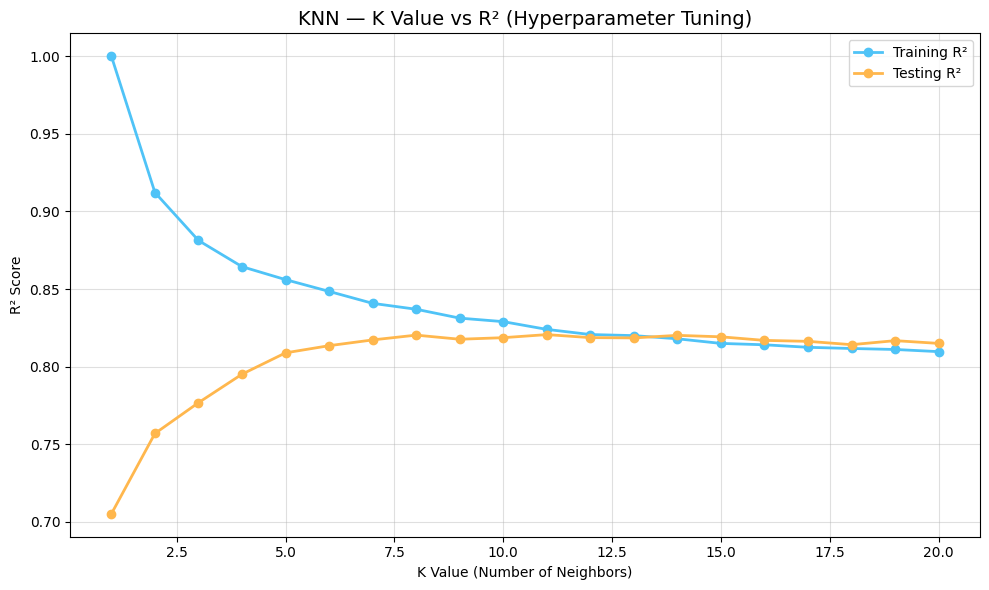

Best K: 11

KNN Results:
  Best K : 11
  MAE    : 60.43 minutes
  RMSE   : 135.65 minutes
  R²     : 0.8207


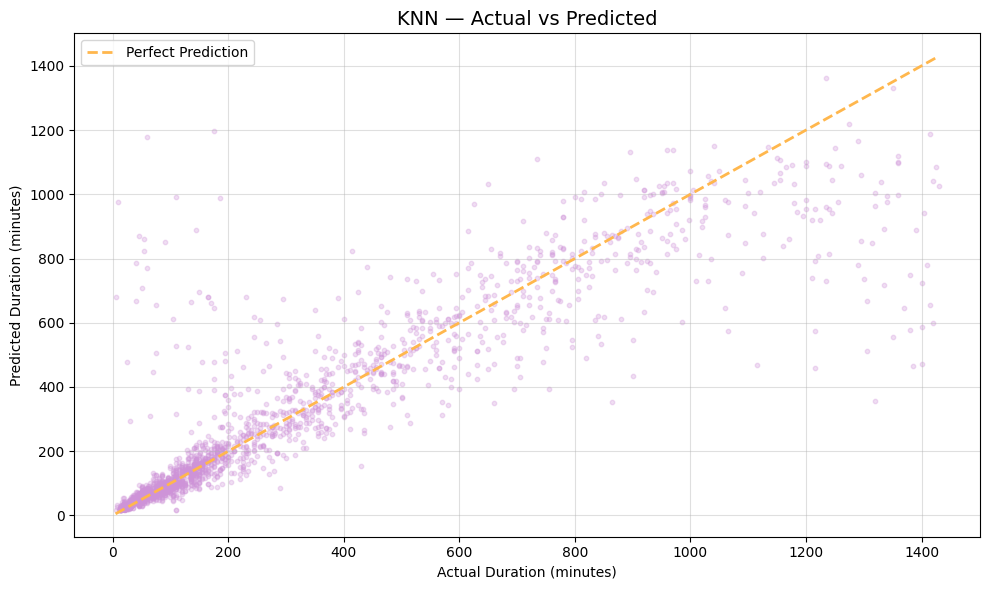

 knn saved to /content/drive/MyDrive/intern/models/knn.pkl


In [19]:
from sklearn.neighbors import KNeighborsRegressor

train_scores = []
test_scores  = []
k_values     = range(1, 21)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(r2_score(y_train, knn.predict(X_train_scaled)))
    test_scores.append(r2_score(y_test,   knn.predict(X_test_scaled)))

#k vs r
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, color="#4FC3F7", linewidth=2, marker="o", label="Training R²")
plt.plot(k_values, test_scores,  color="#FFB74D", linewidth=2, marker="o", label="Testing R²")
plt.title("KNN — K Value vs R² (Hyperparameter Tuning)", fontsize=14)
plt.xlabel("K Value (Number of Neighbors)")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Best K
best_k = k_values[test_scores.index(max(test_scores))]
print(f"Best K: {best_k}")
#train
knn_model = KNeighborsRegressor(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

#
mae  = mean_absolute_error(y_test, y_pred_knn)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2   = r2_score(y_test, y_pred_knn)

print("\nKNN Results:")
print(f"  Best K : {best_k}")
print(f"  MAE    : {mae:.2f} minutes")
print(f"  RMSE   : {rmse:.2f} minutes")
print(f"  R²     : {r2:.4f}")


plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_knn, alpha=0.3, s=10, color="#CE93D8")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="#FFB74D", linewidth=2, linestyle="--", label="Perfect Prediction")
plt.title("KNN — Actual vs Predicted", fontsize=14)
plt.xlabel("Actual Duration (minutes)")
plt.ylabel("Predicted Duration (minutes)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

save_model(knn_model, "knn")


  FINAL MODEL COMPARISON
                      MAE    RMSE      R2
Linear Regression  137.96  221.21  0.5230
Decision Tree       53.47  134.29  0.8242
KNN                 60.43  135.65  0.8207


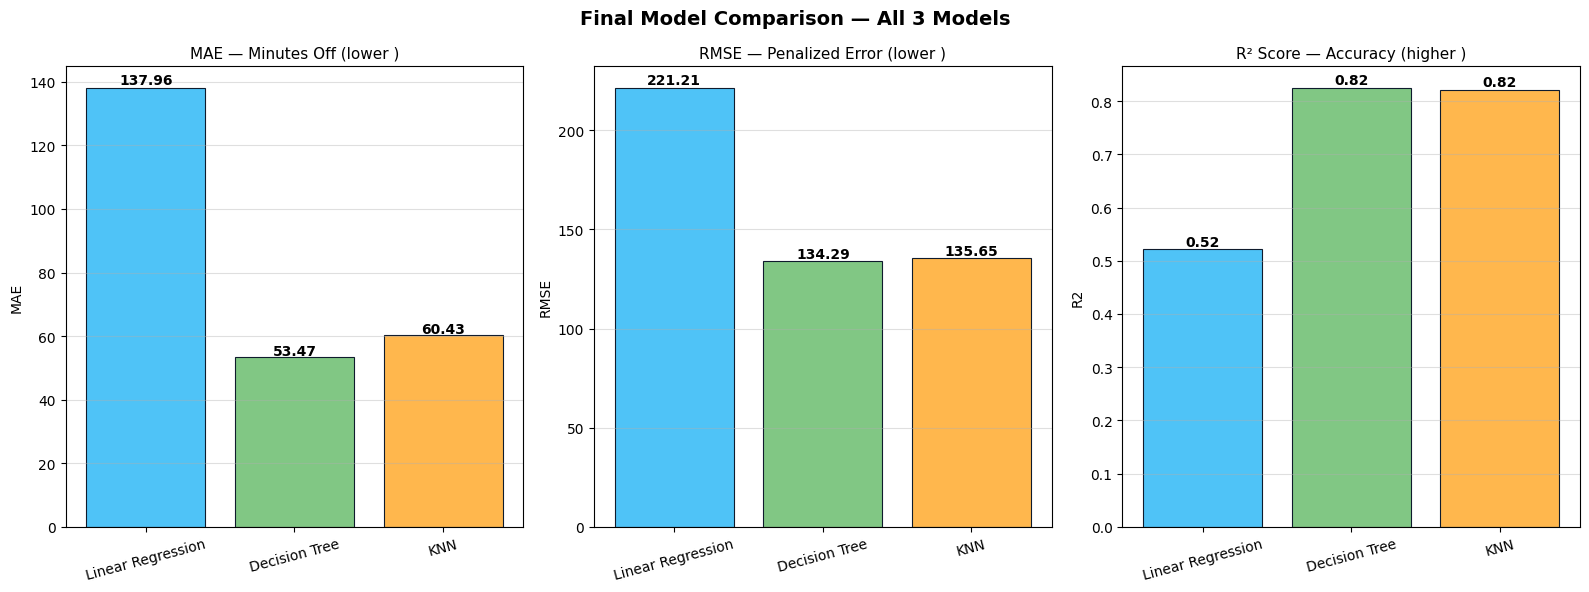

 linear_regression loaded from /content/drive/MyDrive/intern/models/linear_regression.pkl
 decision_tree loaded from /content/drive/MyDrive/intern/models/decision_tree.pkl
 knn loaded from /content/drive/MyDrive/intern/models/knn.pkl


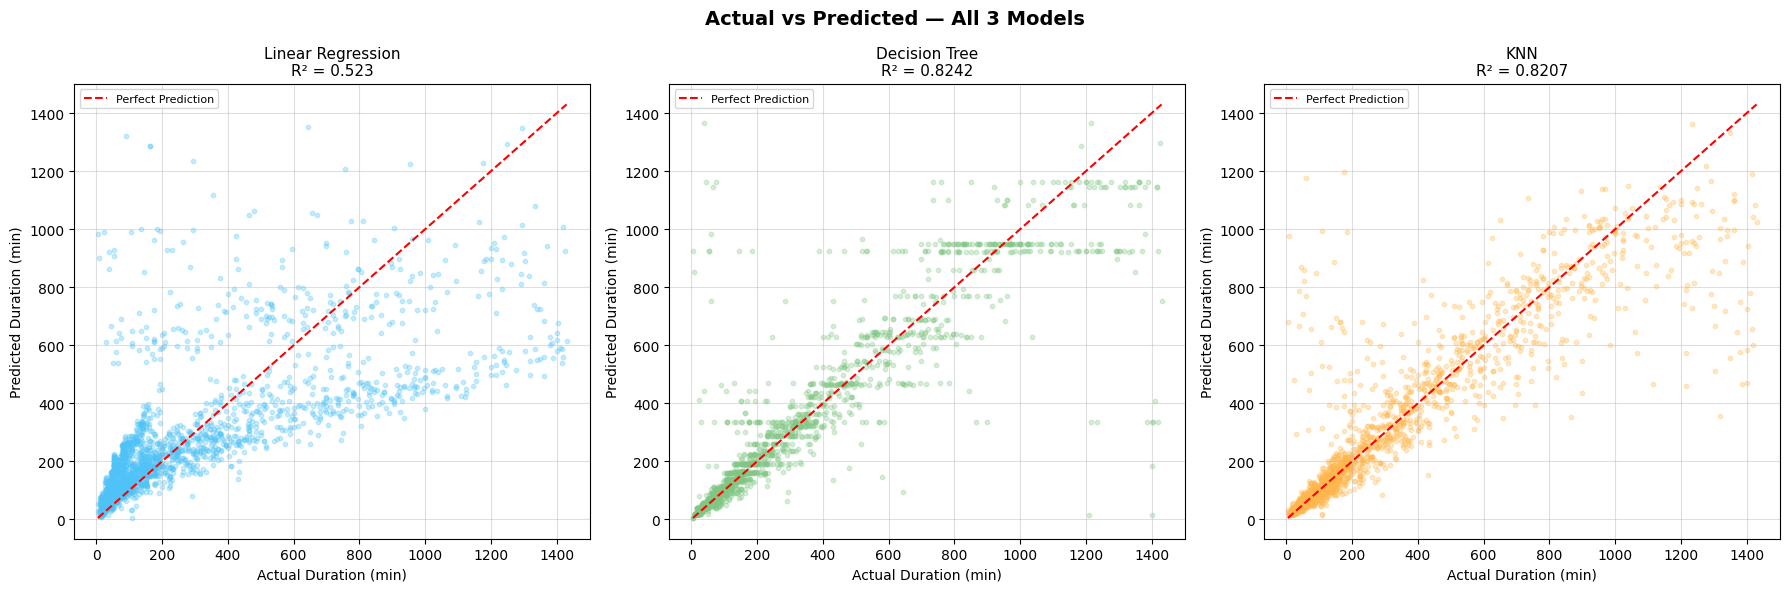


 Best R²   : Decision Tree   (0.8242)
 Best MAE  : Decision Tree  (53.47 minutes)
 Best RMSE : Decision Tree (134.29 minutes)

 Overall Winner: Decision Tree
   → Best balance of R², MAE and RMSE
   → 82% accuracy, only 53 minutes off on average


In [20]:
results = {
    "Linear Regression" : {"MAE": 137.96, "RMSE": 221.21, "R2": 0.5230},
    "Decision Tree"     : {"MAE": 53.47,  "RMSE": 134.29, "R2": 0.8242},
    "KNN"               : {"MAE": 60.43,  "RMSE": 135.65, "R2": 0.8207},
}

results_df = pd.DataFrame(results).T
print("=" * 55)
print("  FINAL MODEL COMPARISON")
print("=" * 55)
print(results_df.to_string())
print("=" * 55)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Final Model Comparison — All 3 Models",
             fontsize=14, fontweight="bold")

model_names = list(results.keys())
colors      = ["#4FC3F7", "#81C784", "#FFB74D"]
metrics     = [
    ("MAE",  "MAE — Minutes Off (lower )"),
    ("RMSE", "RMSE — Penalized Error (lower )"),
    ("R2",   "R² Score — Accuracy (higher )"),
]

for i, (metric, title) in enumerate(metrics):
    values = [results[m][metric] for m in model_names]
    bars   = axes[i].bar(model_names, values, color=colors,
                         edgecolor="#0F1B2D", linewidth=0.8)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 1.01,
                     f"{val:.2f}", ha="center",
                     fontsize=10, fontweight="bold")
    axes[i].set_title(title, fontsize=11)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis="x", rotation=15)
    axes[i].grid(True, axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

y_pred_lr  = load_model("linear_regression").predict(X_test_scaled)
y_pred_dt  = load_model("decision_tree").predict(X_test)
y_pred_knn = load_model("knn").predict(X_test_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Actual vs Predicted — All 3 Models",
             fontsize=14, fontweight="bold")

preds   = [y_pred_lr,  y_pred_dt,  y_pred_knn]
names   = ["Linear Regression", "Decision Tree", "KNN"]
colors  = ["#4FC3F7",  "#81C784",  "#FFB74D"]

for i, (pred, name, color) in enumerate(zip(preds, names, colors)):
    axes[i].scatter(y_test, pred, alpha=0.3, s=10, color=color)
    axes[i].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 color="red", linewidth=1.5,
                 linestyle="--", label="Perfect Prediction")
    axes[i].set_title(f"{name}\nR² = {results[name]['R2']}", fontsize=11)
    axes[i].set_xlabel("Actual Duration (min)")
    axes[i].set_ylabel("Predicted Duration (min)")
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

#summary
best_r2   = results_df["R2"].idxmax()
best_mae  = results_df["MAE"].idxmin()
best_rmse = results_df["RMSE"].idxmin()

print(f"\n Best R²   : {best_r2}   ({results[best_r2]['R2']})")
print(f" Best MAE  : {best_mae}  ({results[best_mae]['MAE']} minutes)")
print(f" Best RMSE : {best_rmse} ({results[best_rmse]['RMSE']} minutes)")
print(f"\n Overall Winner: Decision Tree")
print(f"   → Best balance of R², MAE and RMSE")
print(f"   → 82% accuracy, only 53 minutes off on average")

Model Comparison:
                      MAE    RMSE      R2
Linear Regression  137.96  221.21  0.5230
Decision Tree       53.47  134.29  0.8242
KNN                 60.43  135.65  0.8207


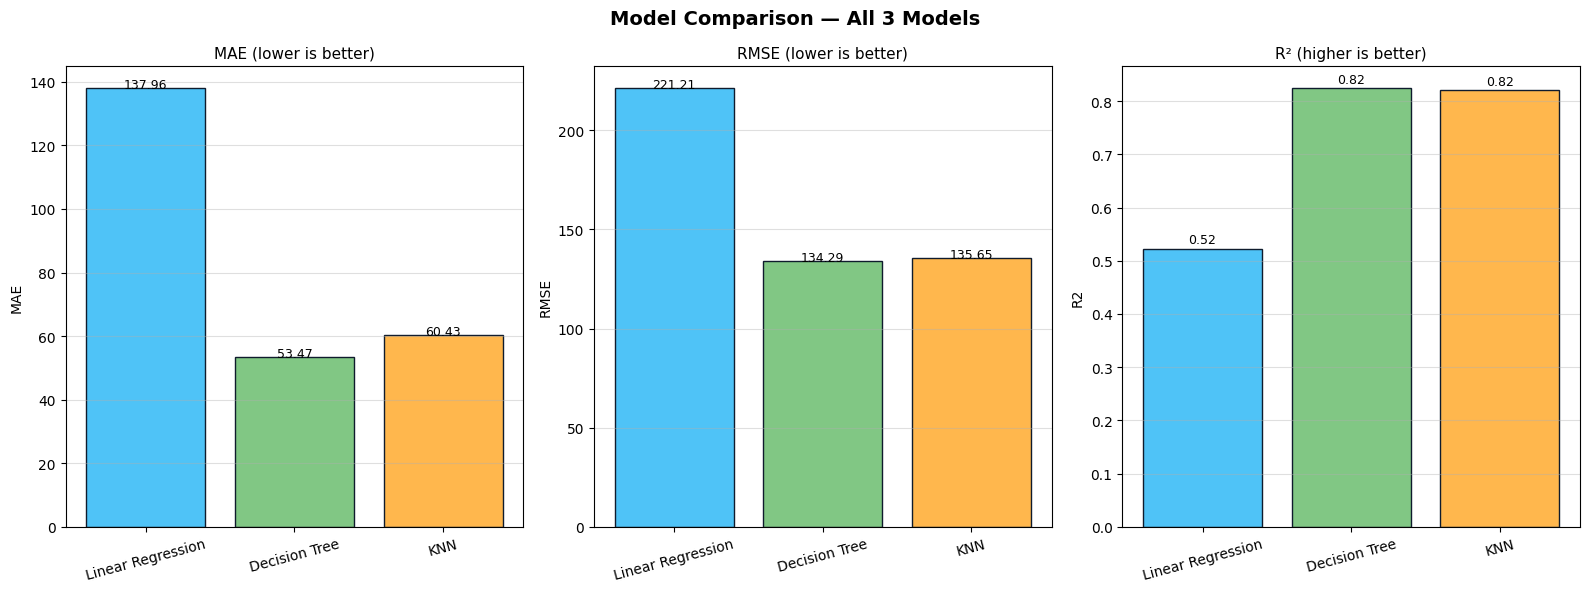


 Best Model: Decision Tree
   MAE  : 53.47
   RMSE : 134.29
   R²   : 0.8242


In [22]:
results = {
    "Linear Regression" : {"MAE": 137.96, "RMSE": 221.21, "R2": 0.5230},
    "Decision Tree"     : {"MAE": 53.47,  "RMSE": 134.29, "R2": 0.8242},
    "KNN"               : {"MAE": 60.43,  "RMSE": 135.65, "R2": 0.8207},
}

results_df = pd.DataFrame(results).T
print("Model Comparison:")
print(results_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Model Comparison — All 3 Models", fontsize=14, fontweight="bold")

metrics = ["MAE", "RMSE", "R2"]
colors  = ["#4FC3F7", "#81C784", "#FFB74D"]
titles  = ["MAE (lower is better)", "RMSE (lower is better)", "R² (higher is better)"]

for i, (metric, title) in enumerate(zip(metrics, titles)):
    values = [results[m][metric] for m in results]
    bars   = axes[i].bar(results.keys(), values, color=colors, edgecolor="#0F1B2D")
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f"{val:.2f}", ha="center", fontsize=9)
    axes[i].set_title(title, fontsize=11)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis="x", rotation=15)
    axes[i].grid(True, axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

# Best model
best_model_name = results_df["R2"].idxmax()
print(f"\n Best Model: {best_model_name}")
print(f"   MAE  : {results[best_model_name]['MAE']}")
print(f"   RMSE : {results[best_model_name]['RMSE']}")
print(f"   R²   : {results[best_model_name]['R2']}")

model prediction on unseen data

 decision_tree loaded from /content/drive/MyDrive/intern/models/decision_tree.pkl
Predictions on Unseen Data:
 Total_Distance  Total_Stops  Predicted_Duration_Min  Predicted_Duration_Hrs
            120            8                  165.82                    2.76
            450           15                  463.33                    7.72
            900           25                  950.53                   15.84
           2000           40                  925.18                   15.42
             50            4                   87.50                    1.46


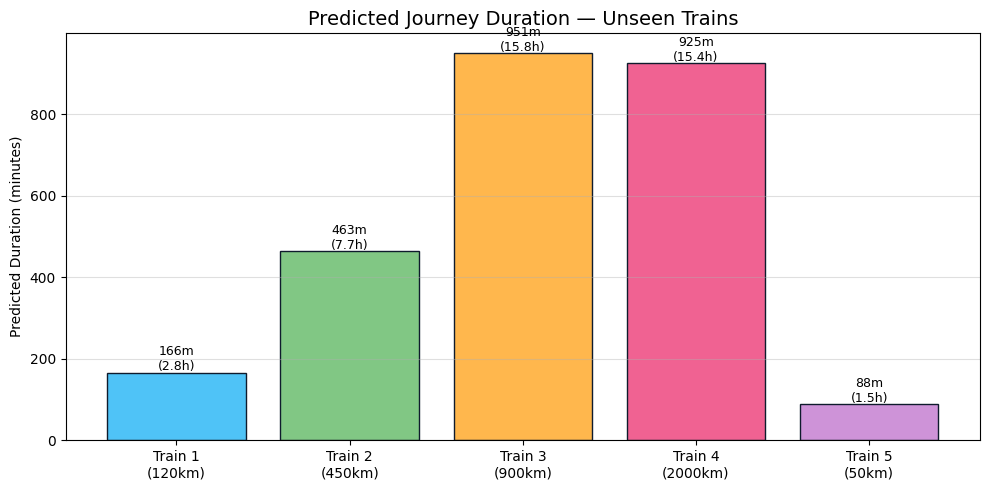

In [23]:
best_model = load_model("decision_tree")

# new data never seen by model
unseen_data = pd.DataFrame({
    "Total_Distance" : [120,  450,  900,  2000, 50  ],
    "Total_Stops"    : [8,    15,   25,   40,   4   ],
    "Avg_1A_Fare"    : [400,  800,  1200, 2500, 200 ],
    "Avg_2A_Fare"    : [300,  600,  900,  1800, 150 ],
    "Avg_3A_Fare"    : [200,  400,  600,  1200, 100 ],
    "Avg_SL_Fare"    : [150,  300,  450,  900,  80  ],
    "Dist_Per_Stop"  : [15,   30,   36,   50,   12  ],
    "Dep_Hour"       : [360,  480,  600,  720,  240 ],
})

# Predict
unseen_predictions = best_model.predict(unseen_data)
unseen_data["Predicted_Duration_Min"] = unseen_predictions.round(2)
unseen_data["Predicted_Duration_Hrs"] = (unseen_predictions / 60).round(2)

print("Predictions on Unseen Data:")
print(unseen_data[["Total_Distance", "Total_Stops",
                    "Predicted_Duration_Min",
                    "Predicted_Duration_Hrs"]].to_string(index=False))


plt.figure(figsize=(10, 5))
plt.bar(range(len(unseen_predictions)), unseen_predictions,
        color=["#4FC3F7","#81C784","#FFB74D","#F06292","#CE93D8"],
        edgecolor="#0F1B2D")
for i, val in enumerate(unseen_predictions):
    plt.text(i, val + 5, f"{val:.0f}m\n({val/60:.1f}h)",
             ha="center", fontsize=9)
plt.xticks(range(len(unseen_predictions)),
           [f"Train {i+1}\n({unseen_data['Total_Distance'].iloc[i]}km)"
            for i in range(len(unseen_predictions))])
plt.title("Predicted Journey Duration — Unseen Trains", fontsize=14)
plt.ylabel("Predicted Duration (minutes)")
plt.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

Validation

Validation Results (reloaded model on test set):
  MAE  : 53.47 minutes
  RMSE : 134.29 minutes
  R²   : 0.8242

  Within ±30 min  : 66.1% of predictions
  Within ±60 min  : 78.4% of predictions
  Within ±120 min : 88.7% of predictions


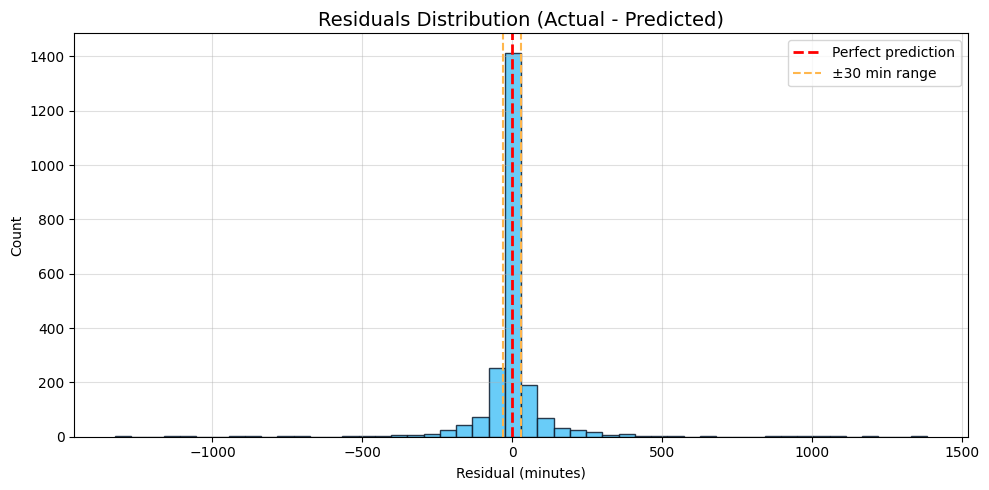

In [24]:
#on test set
y_pred_validate = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_validate)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_validate))
r2   = r2_score(y_test, y_pred_validate)

print("Validation Results (reloaded model on test set):")
print(f"  MAE  : {mae:.2f} minutes")
print(f"  RMSE : {rmse:.2f} minutes")
print(f"  R²   : {r2:.4f}")

residuals = y_test.values - y_pred_validate
within_30  = (np.abs(residuals) <= 30).mean()  * 100
within_60  = (np.abs(residuals) <= 60).mean()  * 100
within_120 = (np.abs(residuals) <= 120).mean() * 100

print(f"\n  Within ±30 min  : {within_30:.1f}% of predictions")
print(f"  Within ±60 min  : {within_60:.1f}% of predictions")
print(f"  Within ±120 min : {within_120:.1f}% of predictions")


plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=50, color="#4FC3F7", edgecolor="#0F1B2D", alpha=0.85)
plt.axvline(0,   color="red",     linestyle="--", lw=2, label="Perfect prediction")
plt.axvline(30,  color="#FFB74D", linestyle="--", lw=1.5, label="±30 min range")
plt.axvline(-30, color="#FFB74D", linestyle="--", lw=1.5)
plt.title("Residuals Distribution (Actual - Predicted)", fontsize=14)
plt.xlabel("Residual (minutes)")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Clustering with group patterns

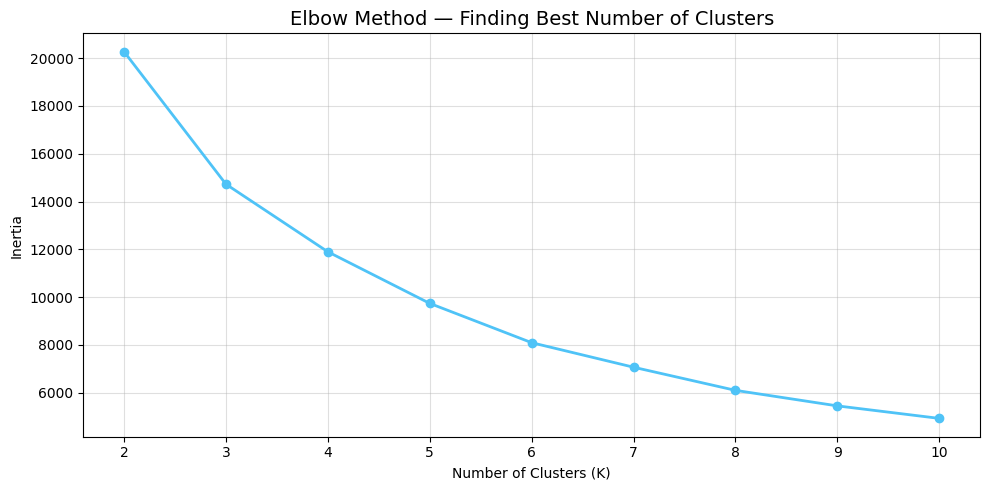

Cluster Patterns:
         Avg_Distance  Avg_Stops  Avg_Fare  Avg_Duration  Count
Cluster                                                        
0              144.44      21.05    243.28        216.07   4062
1             1943.40      32.34   2052.85        561.95   1044
2              746.47      26.17    847.84        908.04   1365
3               52.23       6.70    151.61         80.17   4642


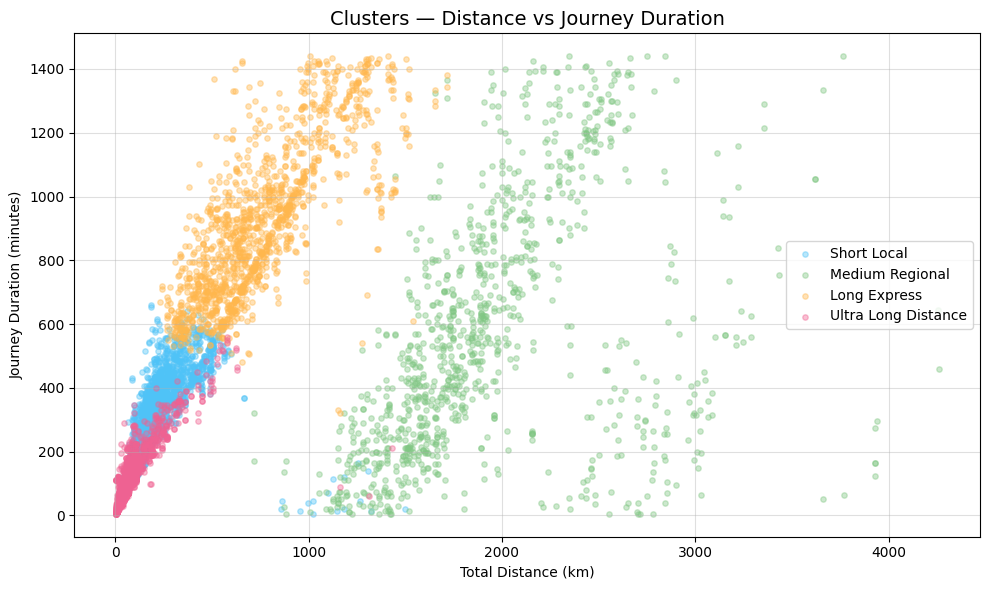

 kmeans saved to /content/drive/MyDrive/intern/models/kmeans.pkl


In [25]:
from sklearn.cluster import KMeans

clustering_features = ["Total_Distance", "Total_Stops",
                        "Avg_SL_Fare", "Journey_Duration_Minutes"]
cluster_data = ml_data[clustering_features].dropna()

# Scale
cluster_scaled = StandardScaler().fit_transform(cluster_data)

# elbow method
inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    inertias.append(km.inertia_)

# Elbow plot
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, color="#4FC3F7", linewidth=2, marker="o")
plt.title("Elbow Method — Finding Best Number of Clusters", fontsize=14)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Apply KMeans with best k
best_k_cluster = 4
kmeans = KMeans(n_clusters=best_k_cluster, random_state=42, n_init=10)
cluster_data = cluster_data.copy()
cluster_data["Cluster"] = kmeans.fit_predict(cluster_scaled)

# Interpret clusters
print("Cluster Patterns:")
cluster_summary = cluster_data.groupby("Cluster").agg(
    Avg_Distance = ("Total_Distance",          "mean"),
    Avg_Stops    = ("Total_Stops",             "mean"),
    Avg_Fare     = ("Avg_SL_Fare",             "mean"),
    Avg_Duration = ("Journey_Duration_Minutes", "mean"),
    Count        = ("Total_Distance",           "count")
).round(2)
print(cluster_summary)

#Label clusters
labels = {
    0: "Short Local",
    1: "Medium Regional",
    2: "Long Express",
    3: "Ultra Long Distance"
}
cluster_data["Cluster_Label"] = cluster_data["Cluster"].map(labels)


plt.figure(figsize=(10, 6))
colors = ["#4FC3F7", "#81C784", "#FFB74D", "#F06292"]
for cluster in range(best_k_cluster):
    mask = cluster_data["Cluster"] == cluster
    plt.scatter(cluster_data[mask]["Total_Distance"],
                cluster_data[mask]["Journey_Duration_Minutes"],
                alpha=0.4, s=15, color=colors[cluster],
                label=labels.get(cluster, f"Cluster {cluster}"))
plt.title("Clusters — Distance vs Journey Duration", fontsize=14)
plt.xlabel("Total Distance (km)")
plt.ylabel("Journey Duration (minutes)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


save_model(kmeans, "kmeans")